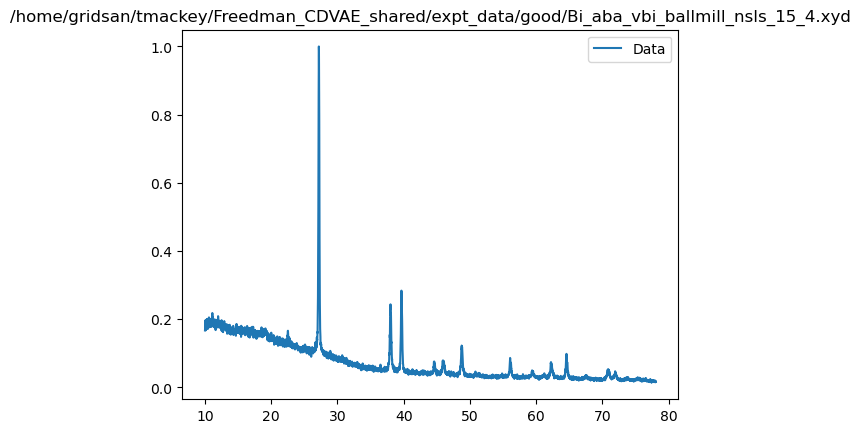

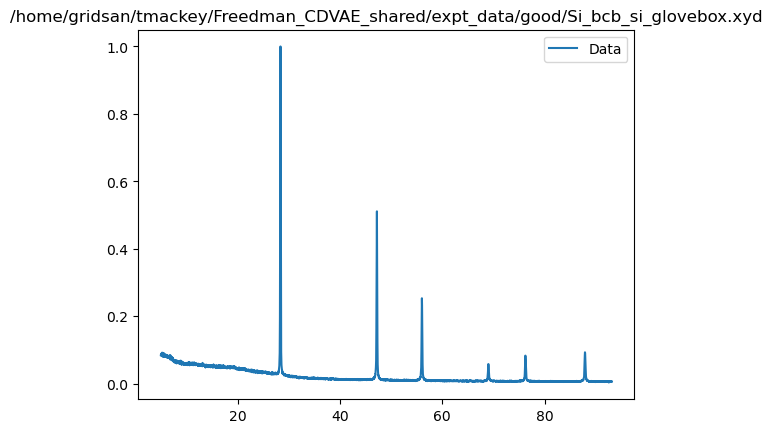

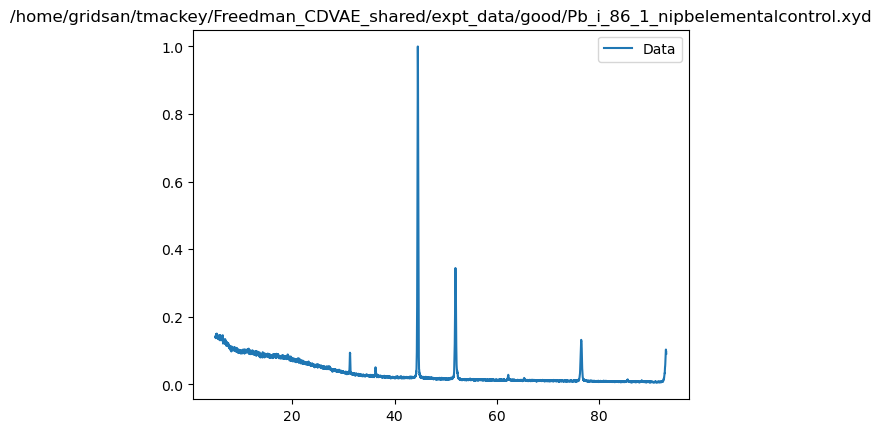

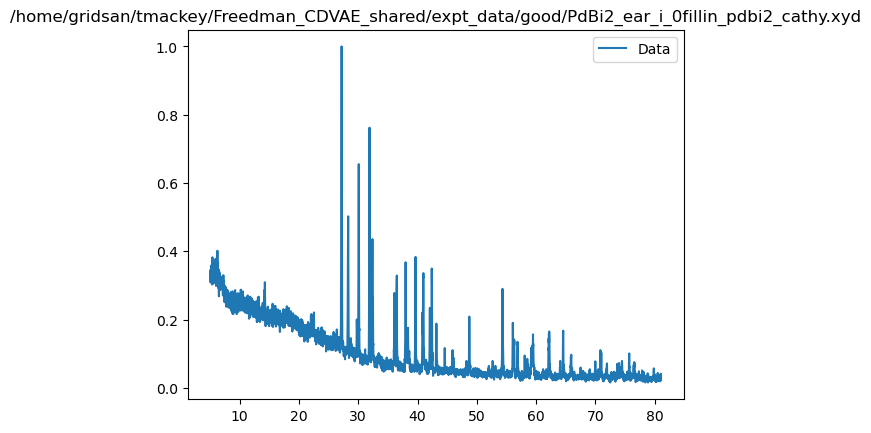

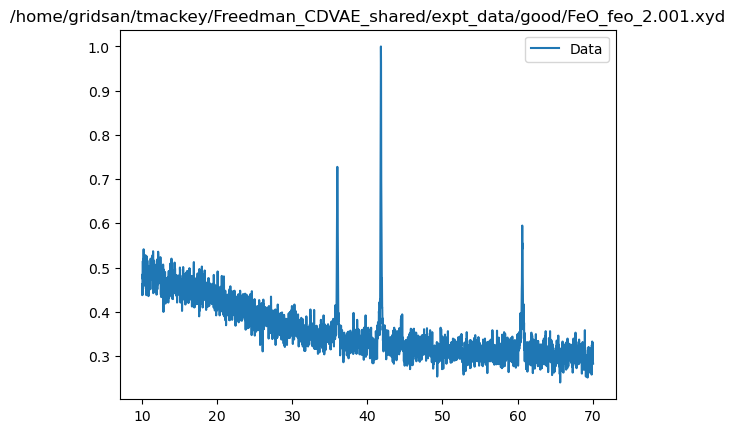

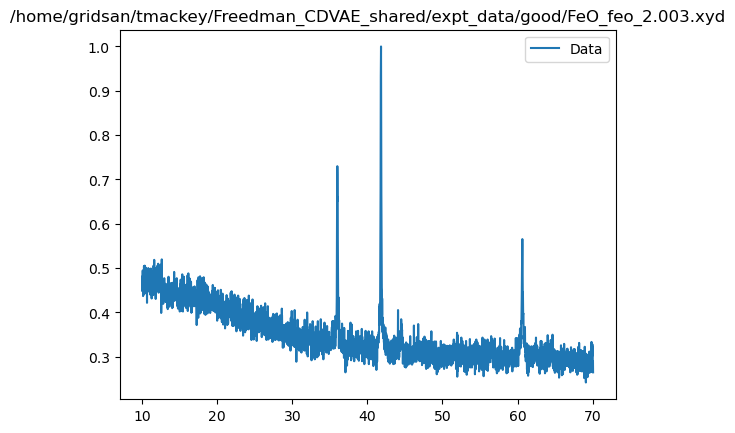

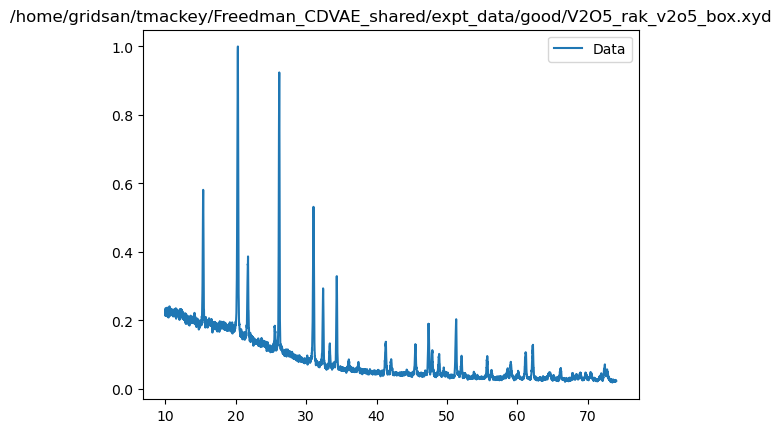

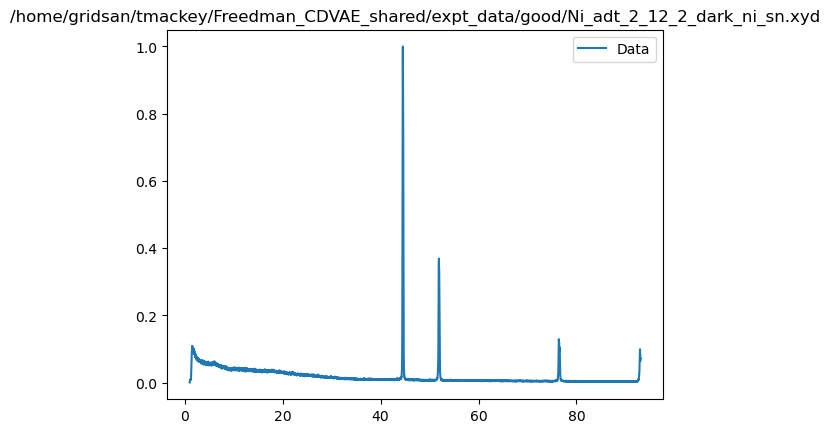

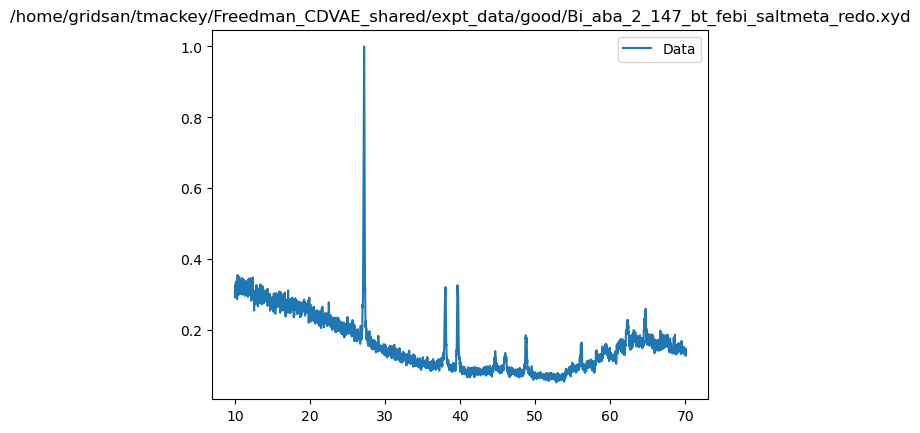

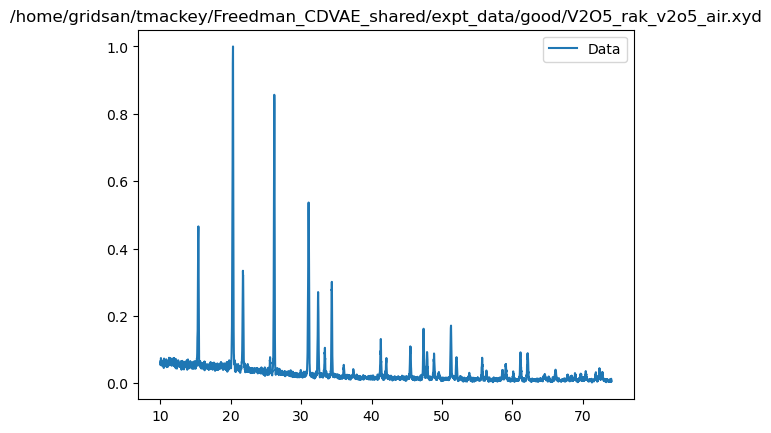

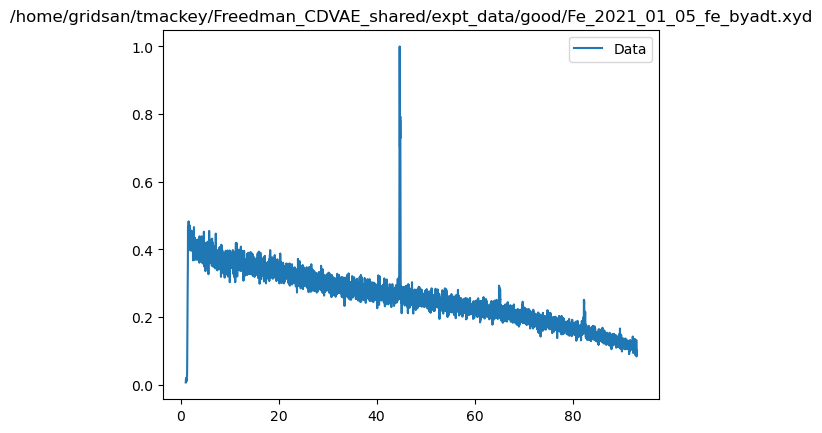

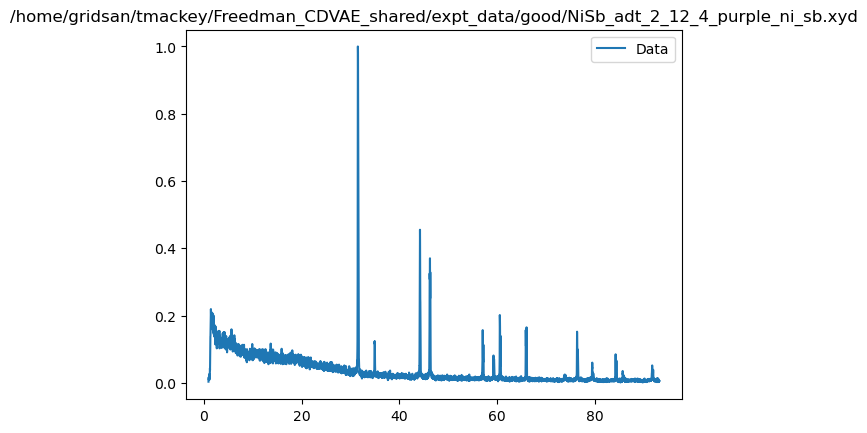

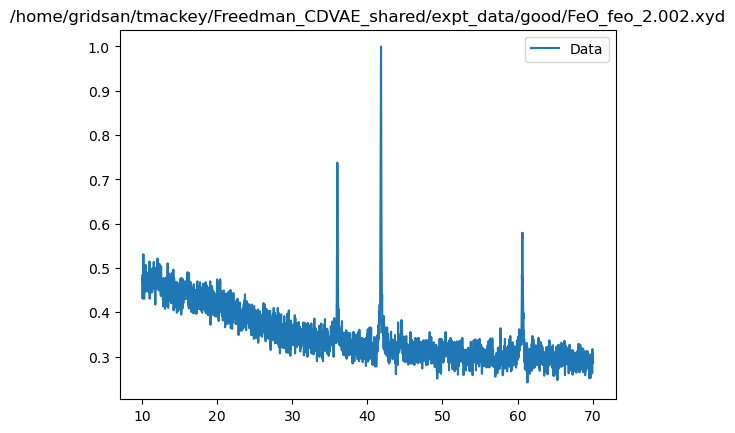

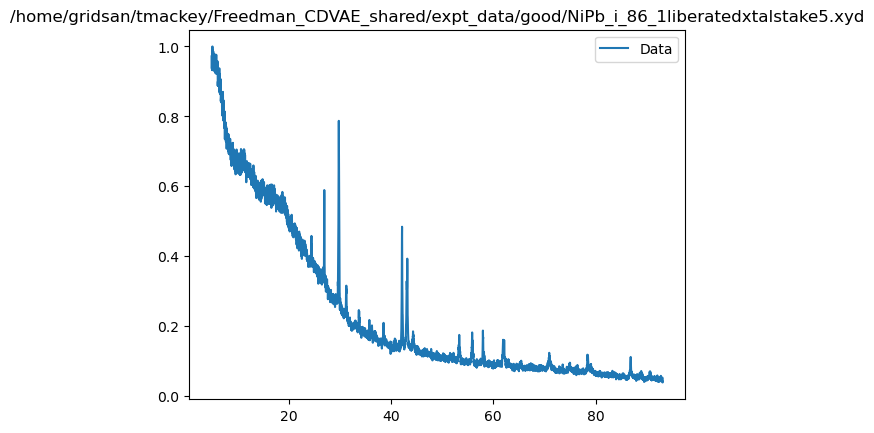

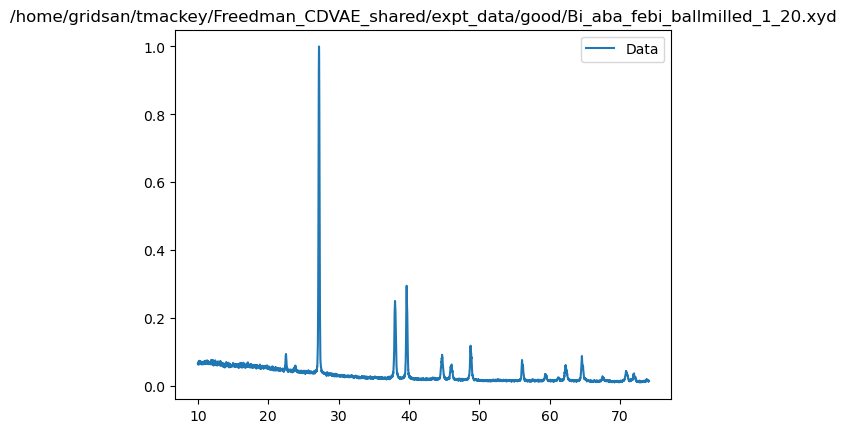

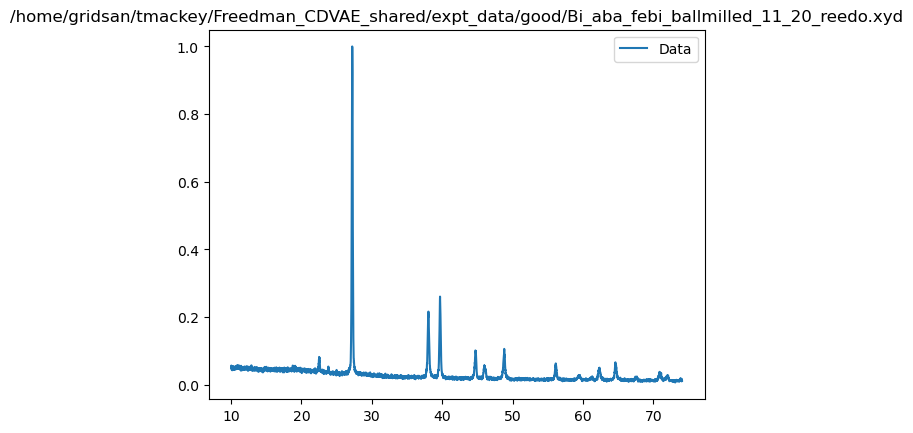

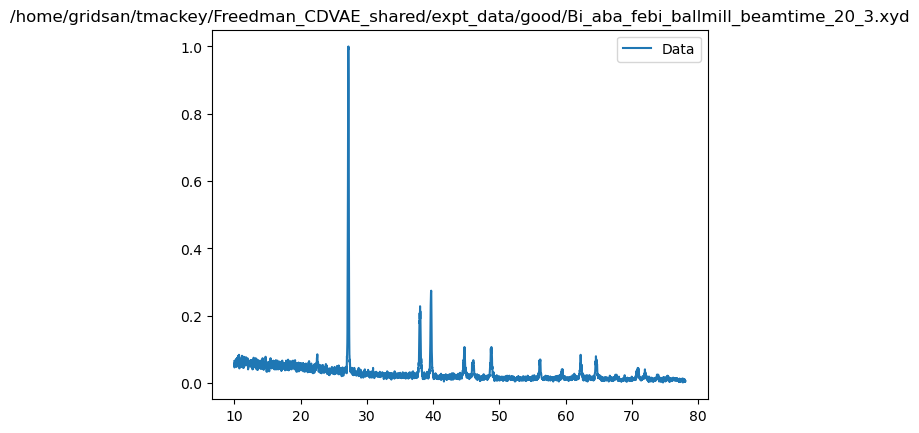

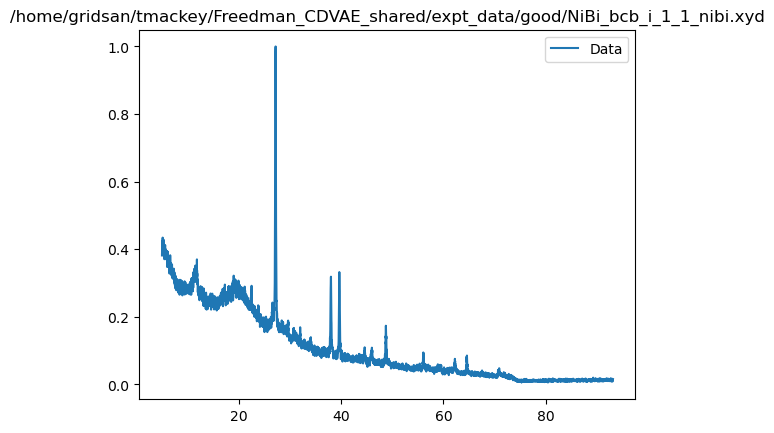

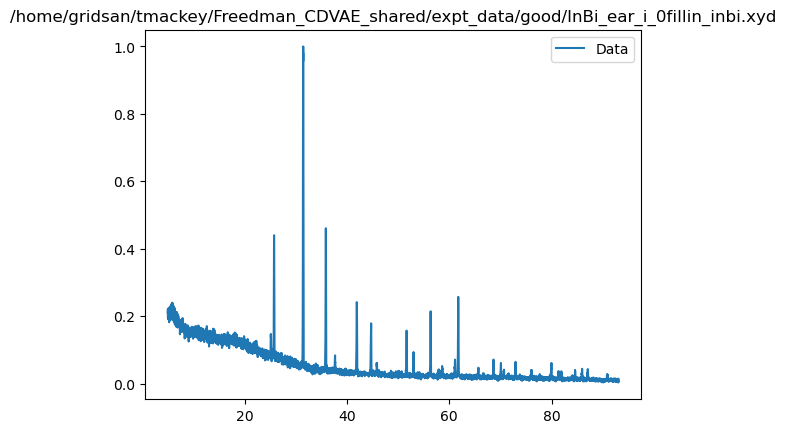

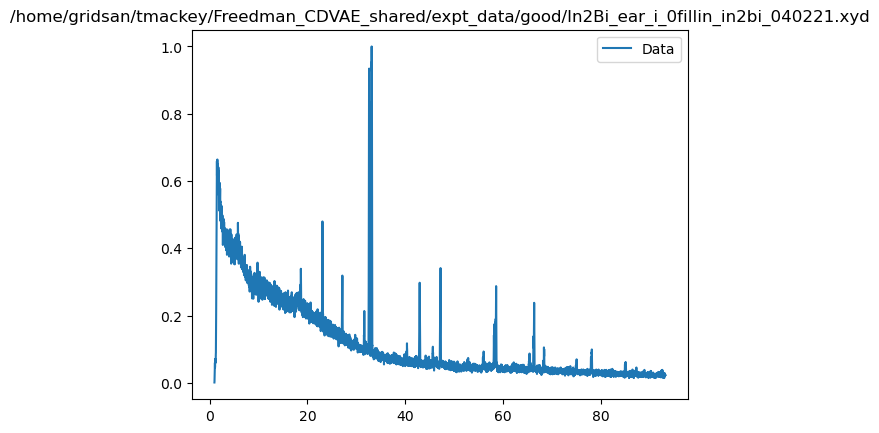

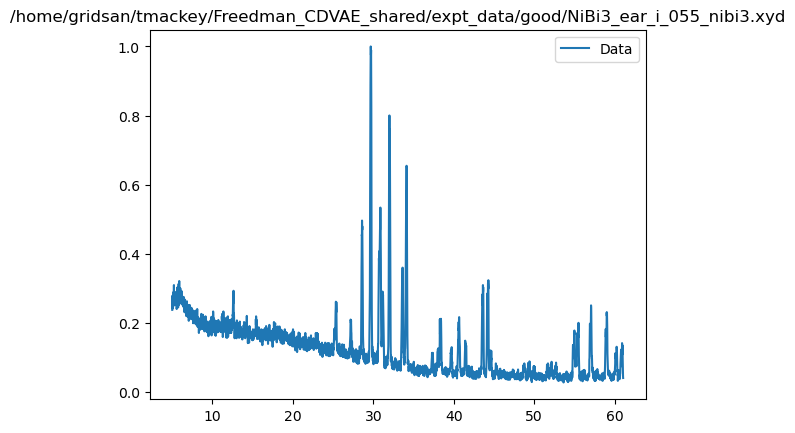

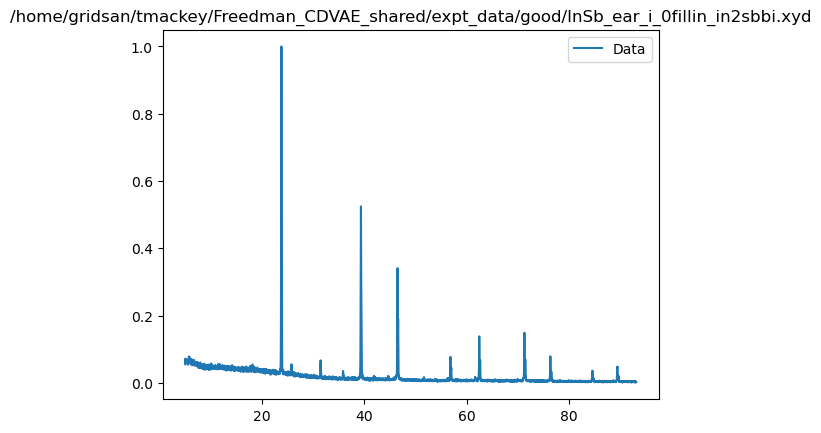

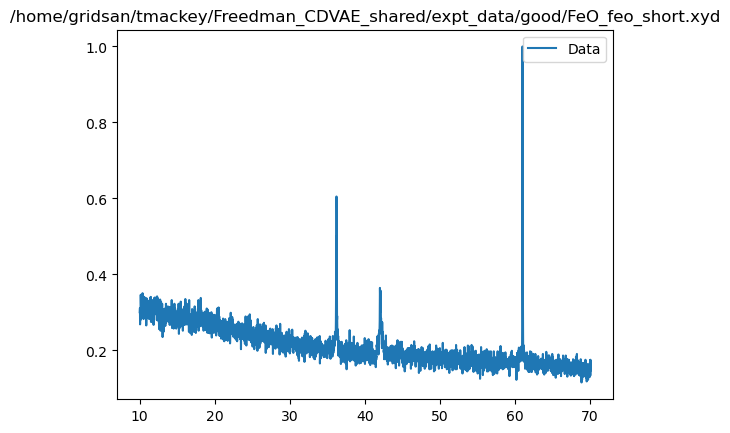

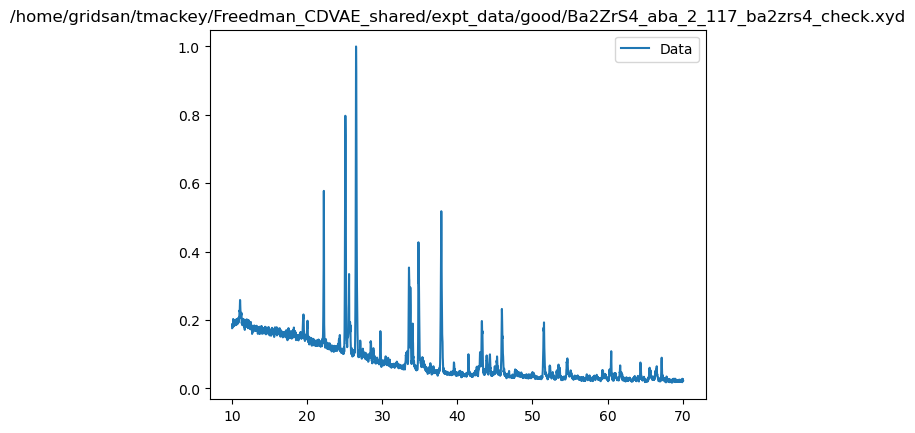

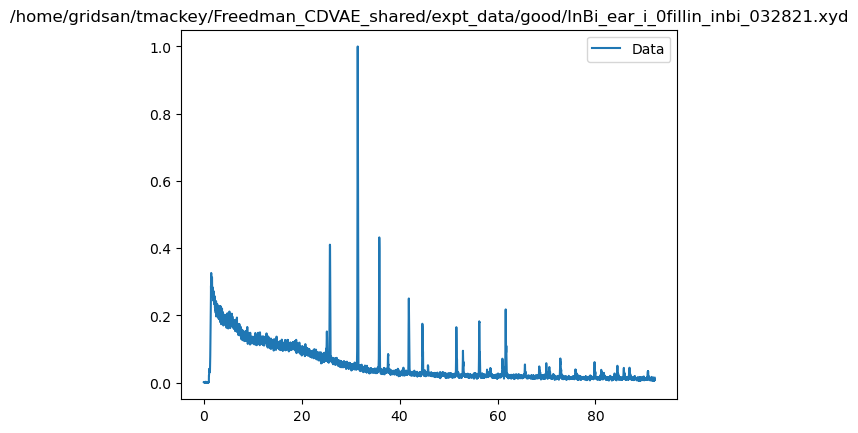

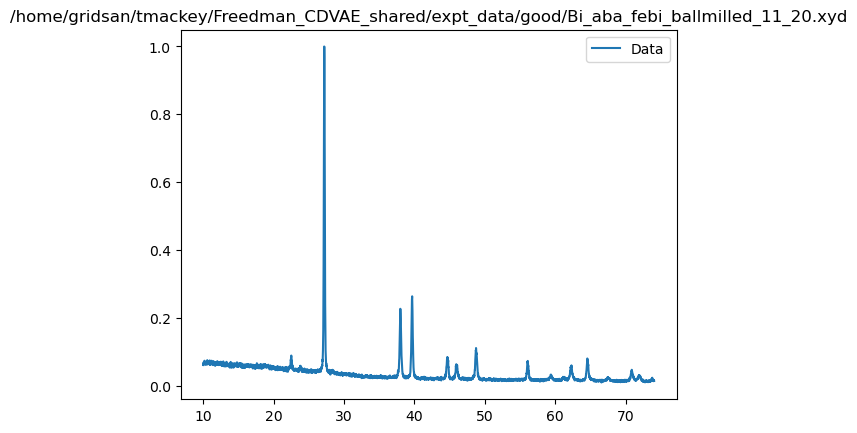

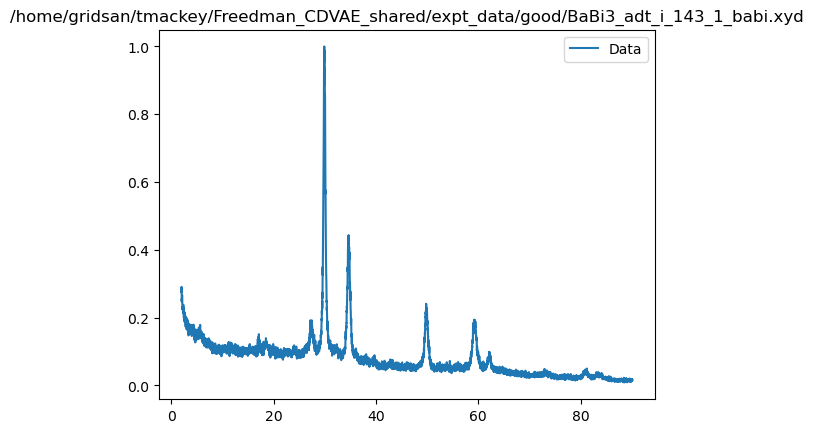

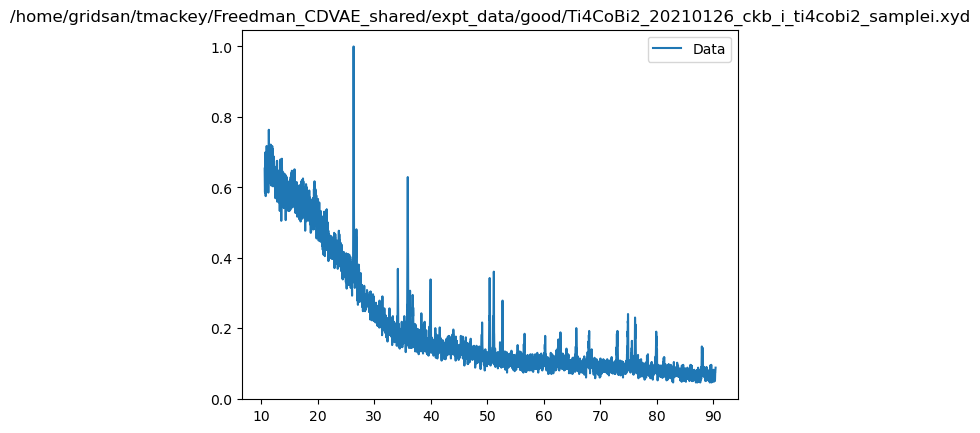

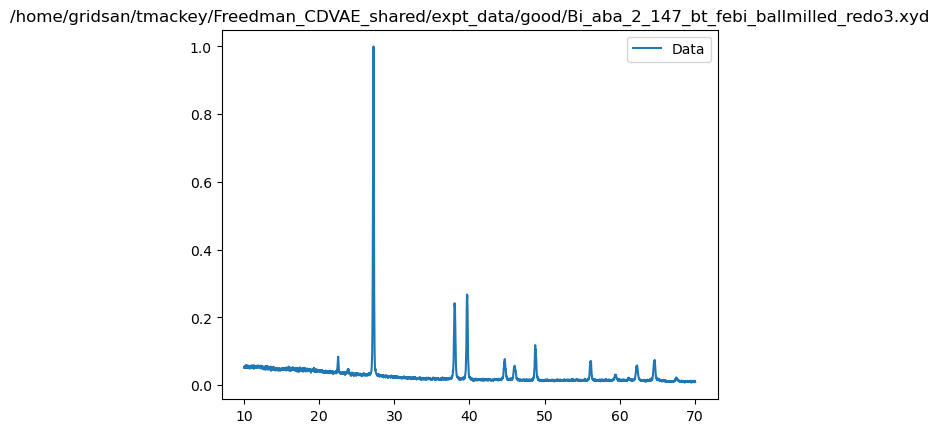

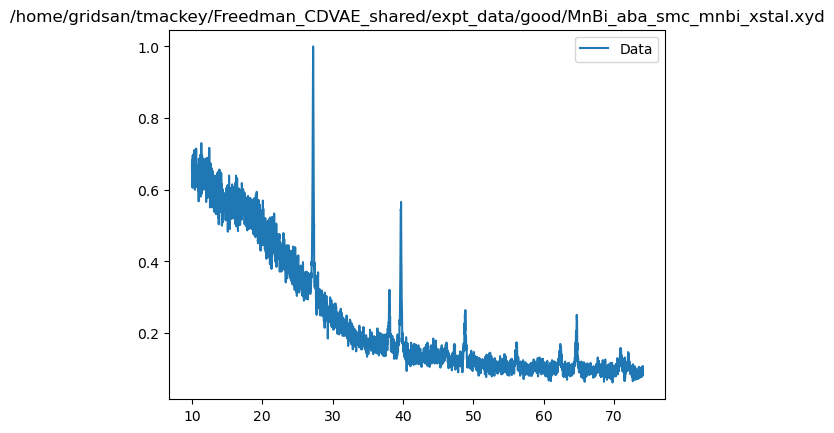

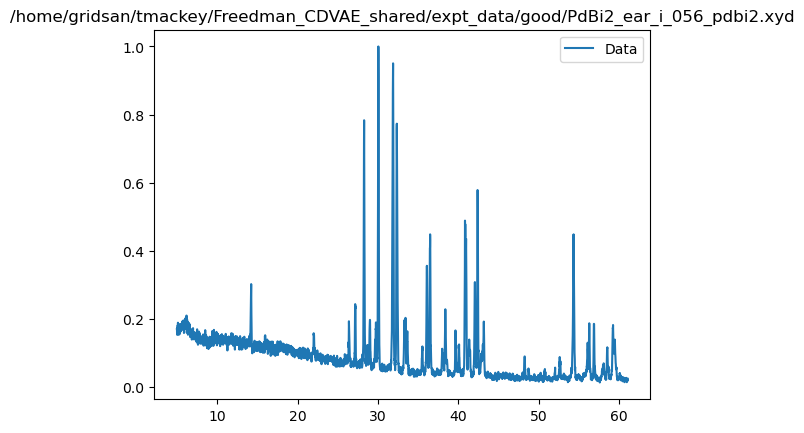

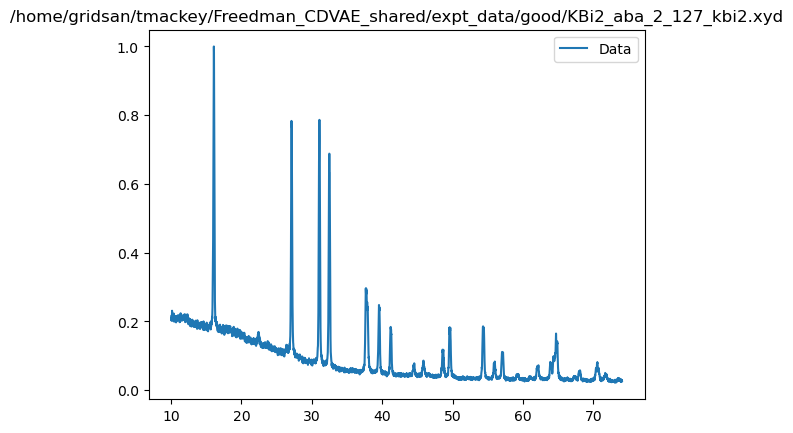

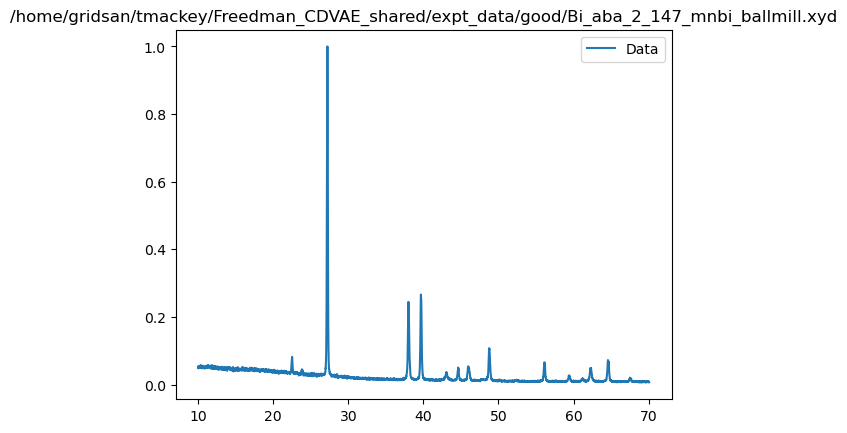

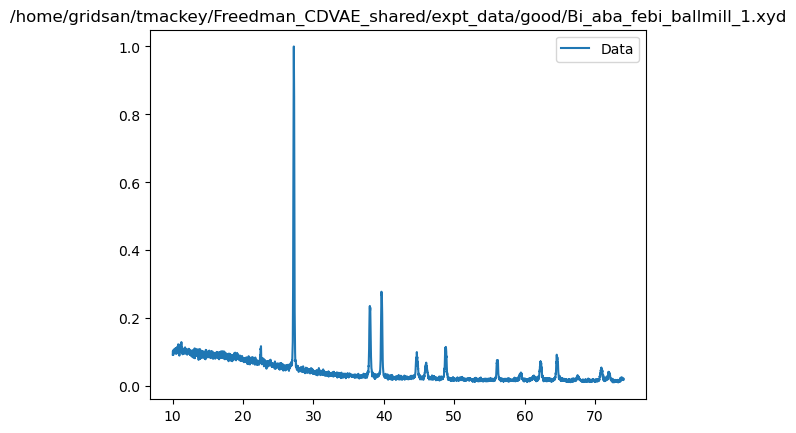

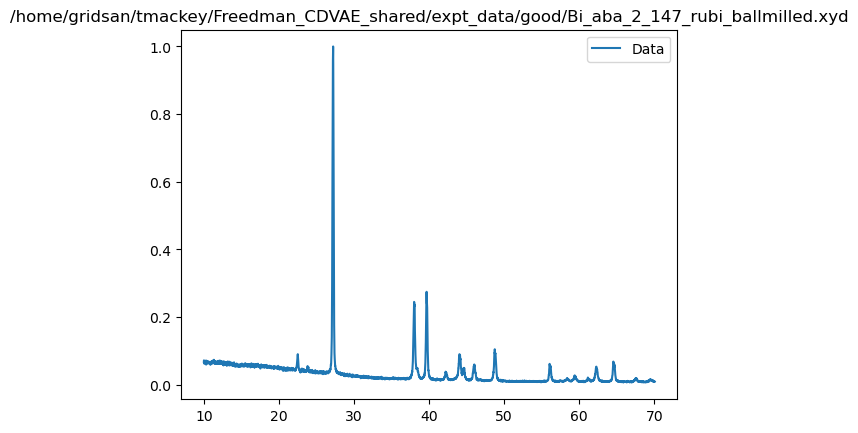

In [17]:
import pandas as pd
from scipy import interpolate, optimize
import matplotlib.pyplot as plt
import numpy as np
import os

file_list = os.listdir("/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good")

def plotter(x, y, fit_y=None):
    plt.figure()
    for i in range(len(x)):
        plt.plot(x[i], y[i], label="Data")
    if fit_y is not None:
        plt.plot(x[0], fit_y, label="Fitted Polynomial", color='red')
    plt.title(file)
    plt.legend()
    plt.show()
    plt.close()

list_totalx = []
list_totaly = []
for file in file_list[:len(file_list)]:
    try: 
        file = "/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good/" + file
        if file.endswith(".xyd"):
            data = pd.read_csv(file, sep='\s+', header=None, names=['x', 'y', 'd'])
            x_data = np.array(data['x'])
            y_data = np.array(data['y'])

            #normalize y vaues 
            y_data = y_data / np.max(y_data)

            # Fit a 6-degree polynomial
            def poly_fit(x, *coeffs):
                return sum(c * x**i for i, c in enumerate(coeffs))

            # Provide an initial guess for the 6 coefficients
            initial_guess = [0] * 10  # Change this to your initial guess

            #popt, _ = optimize.curve_fit(poly_fit, x_data, y_data, p0=initial_guess)

            # Generate fitted y values
            #fit_y = poly_fit(x_data, *popt)

            #subtract fitted y values from data
            #y_data = y_data - fit_y

            list_totalx.append(x_data)
            list_totaly.append(y_data)
            plt.plot(x_data, y_data, label="Data")
            #plt.plot(x_data, fit_y, label="Fitted Polynomial", color='red')

            plt.title(file)
            plt.legend()
            plt.show()
            plt.close()
    except:
        continue


In [47]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test.csv")

9


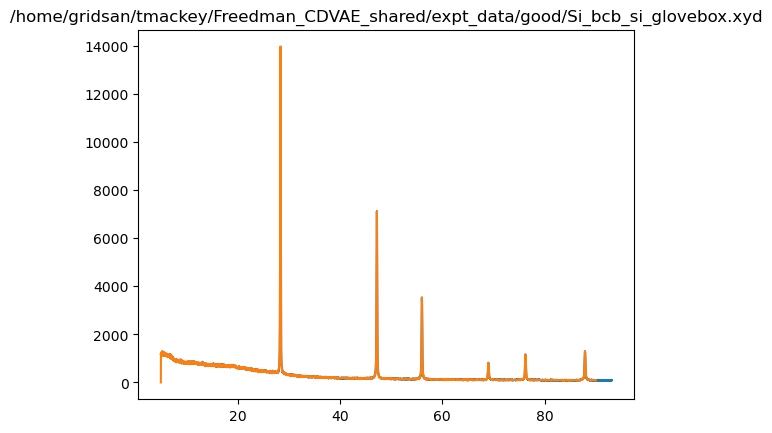

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


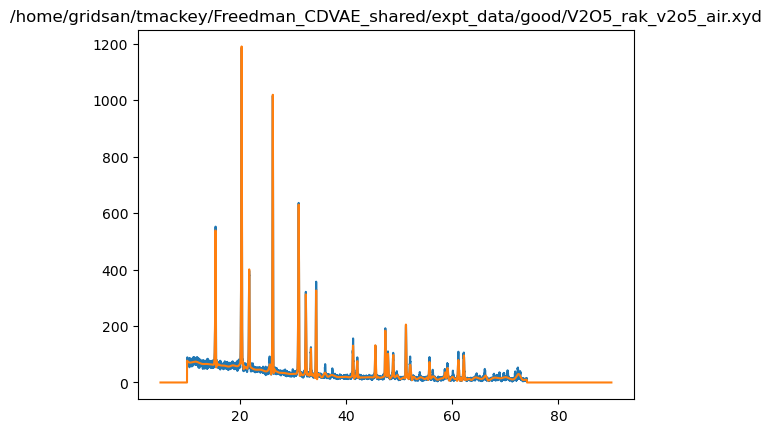

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


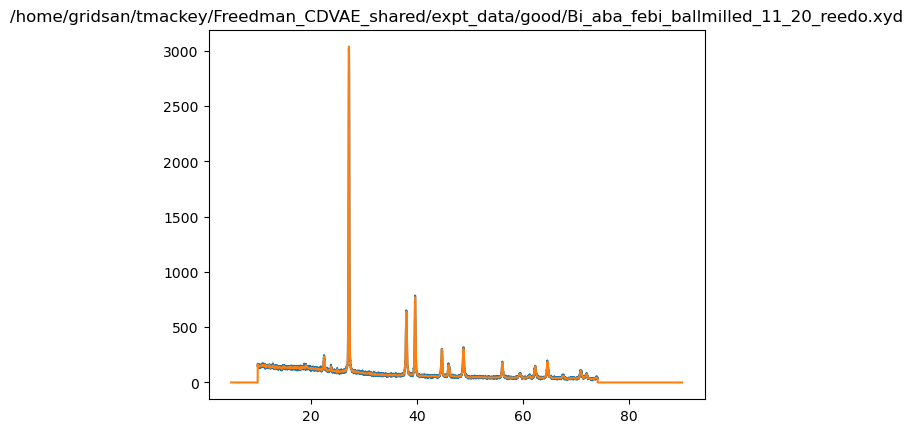

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


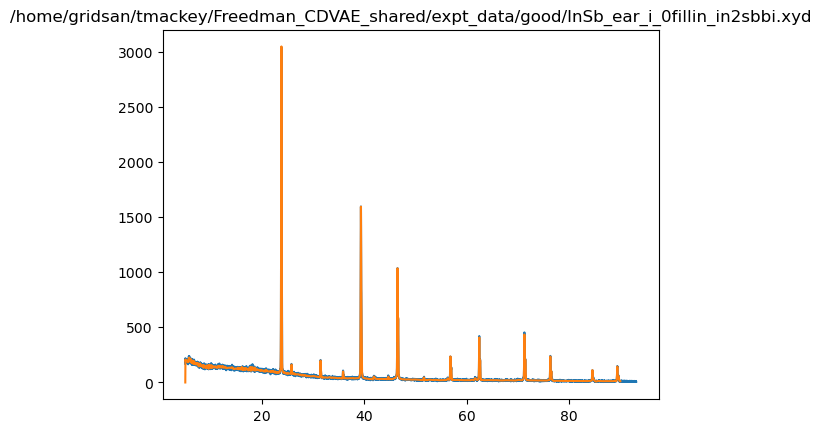

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


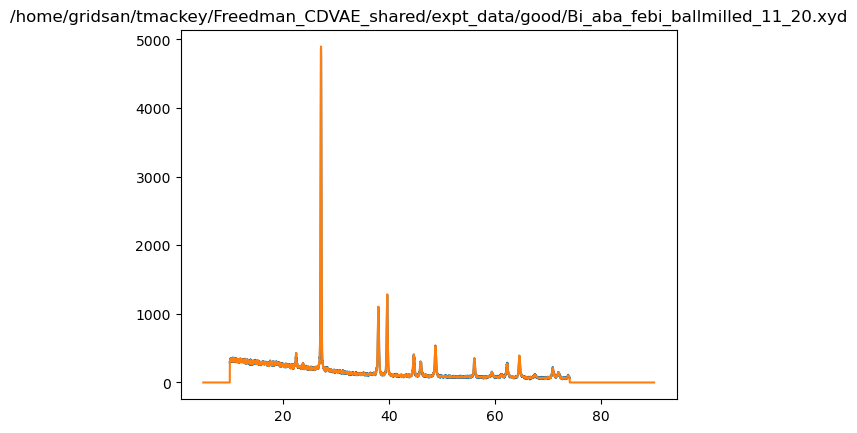

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


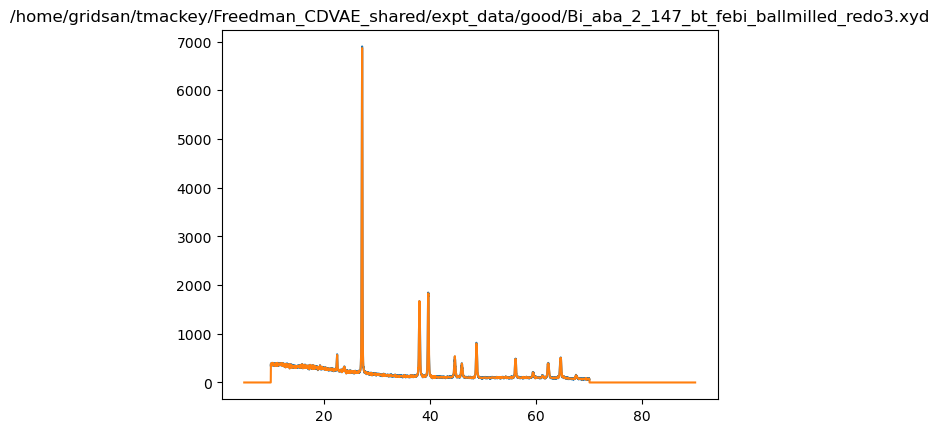

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


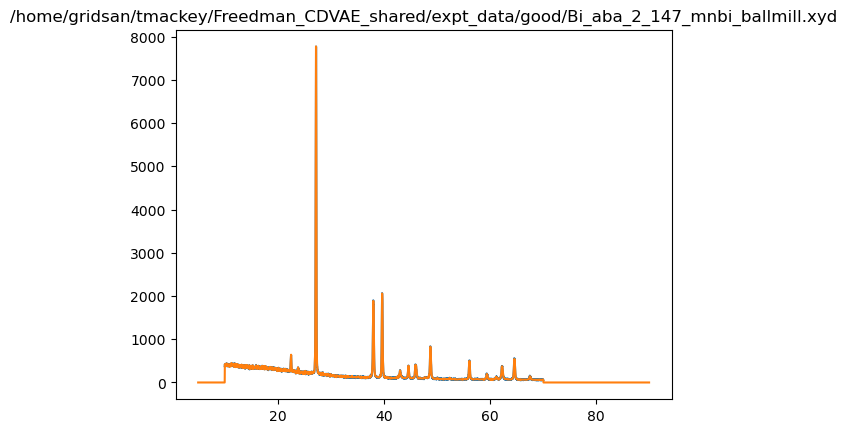

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


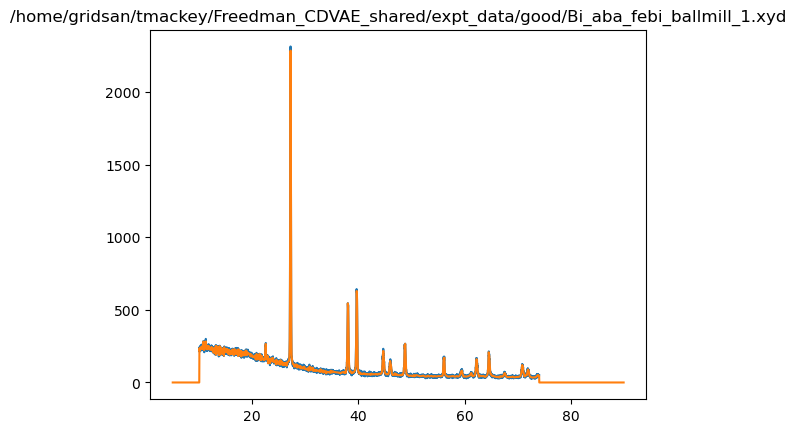

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


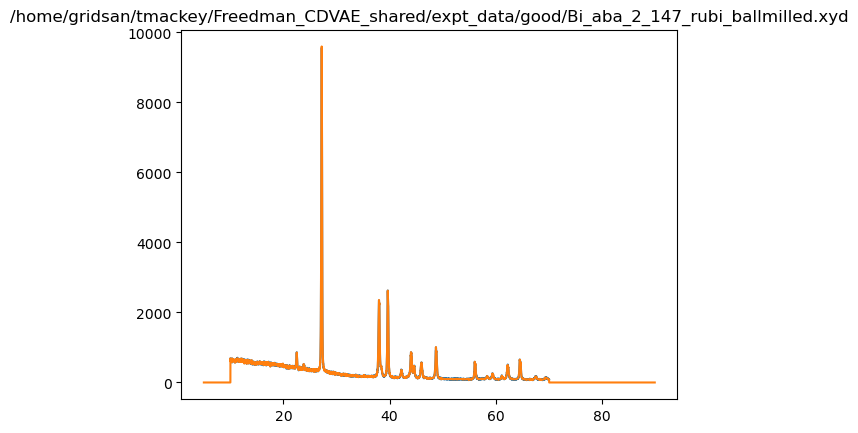

/tmp/ipykernel_84821/4061414352.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['material_id'].iloc[filenum] = filename


In [1]:
import pandas as pd
from scipy import interpolate
import matplotlib.pyplot as plt
import numpy as np
import os
import torch 

test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test.csv")
#shrink the dataframe down to 9 rows
test_df = test_df[:9].copy()

file_list = os.listdir("/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good/")

list_of_files_for_testing = ['Si_bcb_si_glovebox.xyd', 
'V2O5_rak_v2o5_air.xyd', 
'Bi_aba_febi_ballmilled_11_20_reedo.xyd',
'Bi_aba_febi_ballmilled_11_20.xyd',
'InSb_ear_i_0fillin_in2sbbi.xyd',
'Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd',
'Bi_aba_2_147_mnbi_ballmill.xyd',
'Bi_aba_febi_ballmill_1.xyd',
'Bi_aba_2_147_rubi_ballmilled.xyd']

#limit file_list to only files in list_of_files_for_testing
file_list = [x for x in file_list if x in list_of_files_for_testing]
print(len(file_list))

def plotter(x,y):
    plt.figure()
    for i in range(len(x)):
        plt.plot(x[i],y[i])
    plt.title(file)
    #plt.xlim(15, 20)
    #plt.ylim(-100, 200)
    plt.show()
    plt.close()

pseudo_voight_dict = {}

for filenum, filename in enumerate(file_list): 
    file = "/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good/" + filename
    if file.endswith(".xyd"):
        data = pd.read_csv(file, sep='\s+', header=None, names=['x','y','d'])
        my_range = np.arange(5, 90, 0.010)
        smooth_data = interpolate.UnivariateSpline(data['x'], data['y'], k = 3, s = 200000)

        #find the min and max x values 
        min_x = min(data['x'])
        max_x = max(data['x'])

        #initialize results as np zeros in the shape of my_range
        results = np.zeros(len(my_range))

        #use smooth data to set the values of results corresponding to the values in my_range in
        #between the min and max x values
        for i in range(len(my_range)):
            if my_range[i] > min_x and my_range[i] < max_x:
                results[i] = smooth_data(my_range[i])

        max_y = max(data['y'])
        noise_list = []
        plotter([data['x'],my_range],[data['y'],results])

        #set the entry in the 'material_id' column of the test_df dataframe to the filename
        test_df['material_id'].iloc[filenum] = filename

        #convert the results array to a torch tensor
        results = torch.from_numpy(results)

        #reshape to 1 x len(results)
        results = results.reshape(1, len(results))

        #update the dictionary with the results
        pseudo_voight_dict[filename] = results


In [2]:
pseudo_voight_dict

{'Si_bcb_si_glovebox.xyd': tensor([[   0.0000, 1208.4730, 1213.0861,  ...,   90.7512,   91.3668,
            91.8029]], dtype=torch.float64),
 'V2O5_rak_v2o5_air.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'Bi_aba_febi_ballmilled_11_20_reedo.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'InSb_ear_i_0fillin_in2sbbi.xyd': tensor([[  0.0000, 195.1436, 207.5152,  ...,  10.4147,  10.5098,  10.6134]],
        dtype=torch.float64),
 'Bi_aba_febi_ballmilled_11_20.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'Bi_aba_2_147_mnbi_ballmill.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'Bi_aba_febi_ballmill_1.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64),
 'Bi_aba_2_147_rubi_ballmilled.xyd': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64)}

In [3]:
#save the psuedo_voight dict  as .pt file
torch.save(pseudo_voight_dict, '/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test_pv_xrd.pt')

In [57]:
test_df['cif']

0    # generated using pymatgen\ndata_TmMgHg2\n_sym...
1    # generated using pymatgen\ndata_HoWClO4\n_sym...
2    # generated using pymatgen\ndata_NaCaTaTiO6\n_...
3    # generated using pymatgen\ndata_Zn3N2\n_symme...
4    # generated using pymatgen\ndata_GdMgPd\n_symm...
5    # generated using pymatgen\ndata_CaAcZn2\n_sym...
6    # generated using pymatgen\ndata_RbAl(SO4)2\n_...
7    # generated using pymatgen\ndata_LiS4\n_symmet...
8    # generated using pymatgen\ndata_PmMg\n_symmet...
Name: cif, dtype: object

In [58]:
len(test_df['cif'])

9

In [59]:
cif_file_names = ['Si.cif', 'V2O5.cif', 'Bi.cif', 'Bi.cif', 'InSb.cif', 'Bi.cif', 'Bi.cif', 'Bi.cif', 'Bi.cif']
cif_dir = "/home/gridsan/tmackey/CIFs_good_patterns/"

#get the value in the cif column of the test_df dataframe to the content of the cif file
for i in range(len(test_df['cif'])):
    test_df['cif'].iloc[i] = open(cif_dir + cif_file_names[i]).read()

/tmp/ipykernel_3589418/820045478.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['cif'].iloc[i] = open(cif_dir + cif_file_names[i]).read()
/tmp/ipykernel_3589418/820045478.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['cif'].iloc[i] = open(cif_dir + cif_file_names[i]).read()
/tmp/ipykernel_3589418/820045478.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['cif'].iloc[i] = open(cif_dir + cif_file_nam

In [62]:
#save the new test_df dataframe to a csv file
test_df.to_csv("/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test.csv", index=False)

In [1]:
import pandas as pd
import torch 
import numpy as np

RuntimeError: KeyboardInterrupt: 

In [ ]:
pv_dict = torch.load("/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test_pv_xrd.pt")

In [63]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import copy
import itertools

from pymatgen.core.structure import Structure
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis import local_env

from networkx.algorithms.components import is_connected

from sklearn.metrics import accuracy_score, recall_score, precision_score

from torch_scatter import scatter

from p_tqdm import p_umap

import ast
#import the random function library
import random

import os 

from tqdm.auto import tqdm
tqdm.pandas()

CrystalNN = local_env.CrystalNN(
    distance_cutoffs=None, x_diff_weight=-1, porous_adjustment=False)

from cdvae.common.data_utils import * 

import sys

def build_crystal(crystal_str, niggli=True, primitive=False):
    try: 
        """Build crystal from cif string."""
        crystal = Structure.from_str(crystal_str, fmt='cif')

        if primitive:
            crystal = crystal.get_primitive_structure()

        if niggli:
            crystal = crystal.get_reduced_structure()

        canonical_crystal = Structure(
            lattice=Lattice.from_parameters(*crystal.lattice.parameters),
            species=crystal.species,
            coords=crystal.frac_coords,
            coords_are_cartesian=False,
        )
        # match is gaurantteed because cif only uses lattice params & frac_coords
        # assert canonical_crystal.matches(crystal)
        return canonical_crystal
    except: 
        return None 


def build_crystal_graph(crystal, graph_method='crystalnn'):
    try: 
        """
        """

        if graph_method == 'crystalnn':
            crystal_graph = StructureGraph.with_local_env_strategy(
                crystal, CrystalNN)
        elif graph_method == 'none':
            pass
        else:
            raise NotImplementedError

        frac_coords = crystal.frac_coords
        atom_types = crystal.atomic_numbers
        lattice_parameters = crystal.lattice.parameters
        lengths = lattice_parameters[:3]
        angles = lattice_parameters[3:]

        assert np.allclose(crystal.lattice.matrix,
                        lattice_params_to_matrix(*lengths, *angles))

        edge_indices, to_jimages = [], []
        if graph_method != 'none':
            for i, j, to_jimage in crystal_graph.graph.edges(data='to_jimage'):
                edge_indices.append([j, i])
                to_jimages.append(to_jimage)
                edge_indices.append([i, j])
                to_jimages.append(tuple(-tj for tj in to_jimage))

        atom_types = np.array(atom_types)
        lengths, angles = np.array(lengths), np.array(angles)
        edge_indices = np.array(edge_indices)
        to_jimages = np.array(to_jimages)
        num_atoms = atom_types.shape[0]

        return frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms
    except: 
        return None
    

#load in the data 
data_dir = '/home/gridsan/tmackey/cdvae/data/freedman_lab_test/'
test_df = pd.read_csv(data_dir + 'test.csv')

data_frames = {"test": test_df}

for name, df in data_frames.items():
    sub_df = df.copy()
    sub_crystals = sub_df['cif'].progress_apply(build_crystal)
    sub_graphs = sub_crystals.progress_apply(build_crystal_graph)

    materials_ids = sub_df['material_id'].values

    #make a dictionary using the materials_ids as keys and the graphs as values
    graph_dict = dict(zip(materials_ids, sub_graphs))

    #save the dictionary to a file
    torch.save(graph_dict, data_dir + 'test.pt')

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

In [64]:
import pandas as pd

In [70]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/freedman_lab_test/test.csv")

In [71]:
test_df['atomic_numbers']

0                                     [69, 12, 80, 80]
1     [67, 67, 74, 74, 17, 17, 8, 8, 8, 8, 8, 8, 8, 8]
2    [11, 11, 20, 20, 73, 73, 22, 22, 8, 8, 8, 8, 8...
3    [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 3...
4                 [64, 64, 64, 12, 12, 12, 46, 46, 46]
5                                     [20, 89, 30, 30]
6             [37, 13, 16, 16, 8, 8, 8, 8, 8, 8, 8, 8]
7               [3, 3, 16, 16, 16, 16, 16, 16, 16, 16]
8                                             [61, 12]
Name: atomic_numbers, dtype: object

In [72]:
cif_file_names = ['Si.cif', 'V2O5.cif', 'Bi.cif', 'Bi.cif', 'InSb.cif', 'Bi.cif', 'Bi.cif', 'Bi.cif', 'Bi.cif']

In [73]:
atomic_numbers_list = [[14],
                       [23, 8],
                       [83],
                       [83],
                       [49, 51],
                       [83],
                       [83],
                       [83],
                       [83]]

In [74]:
#set the value in the 'atomic_numbers' column of the test_df dataframe to the atomic numbers list
test_df['atomic_numbers'] = atomic_numbers_list

In [75]:
test_df['atomic_numbers']

0        [14]
1     [23, 8]
2        [83]
3        [83]
4    [49, 51]
5        [83]
6        [83]
7        [83]
8        [83]
Name: atomic_numbers, dtype: object

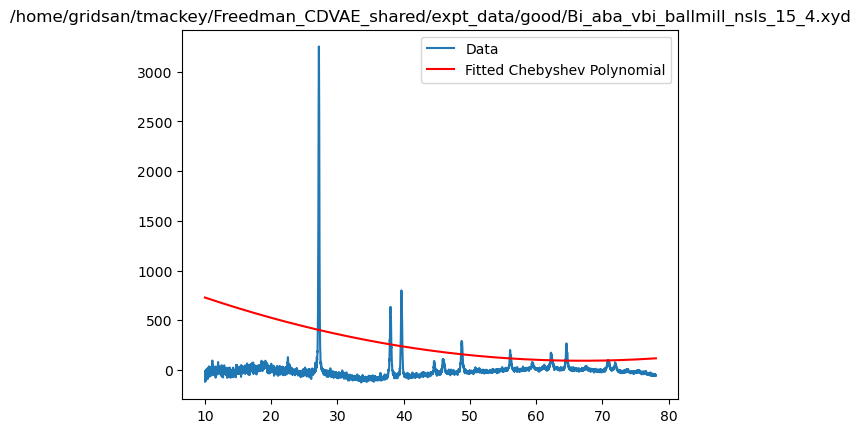

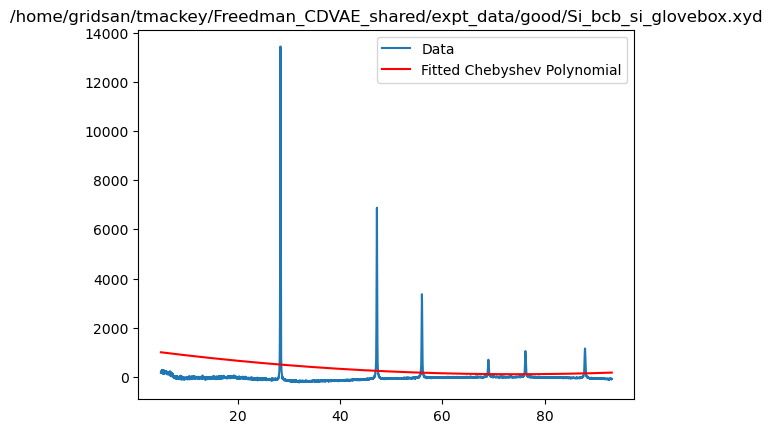

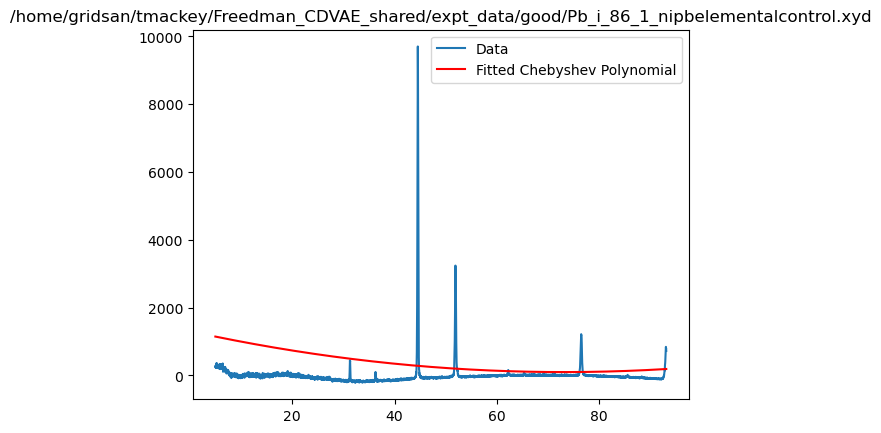

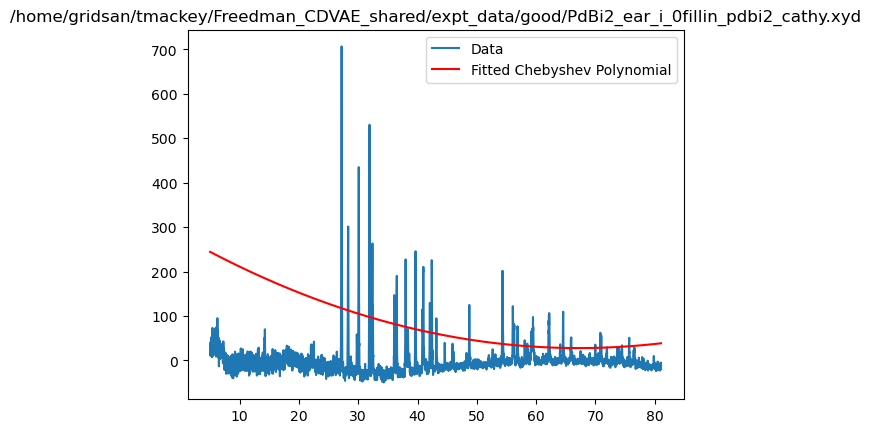

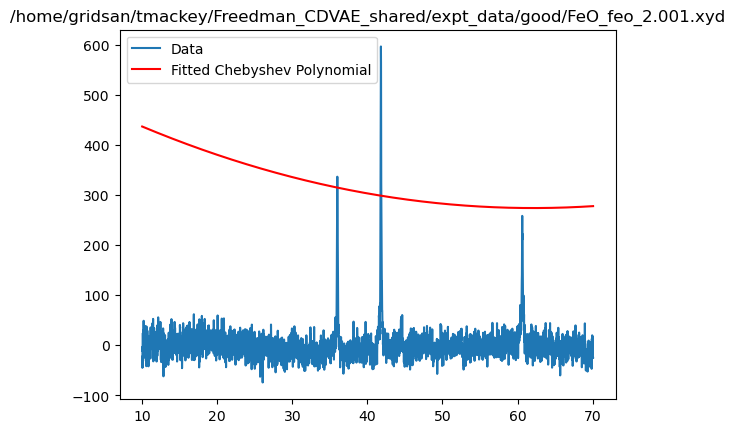

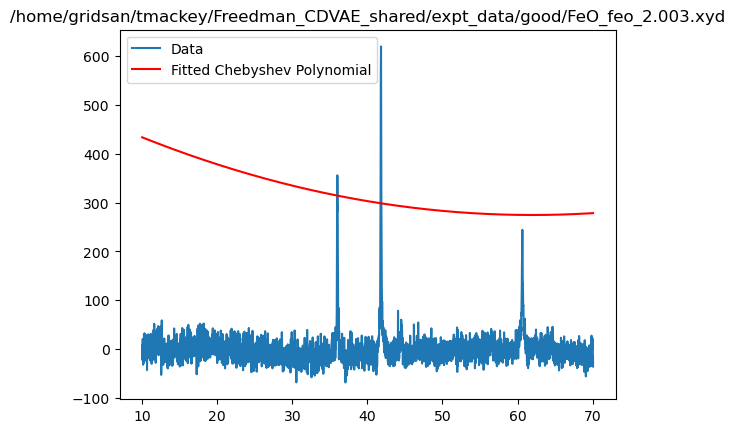

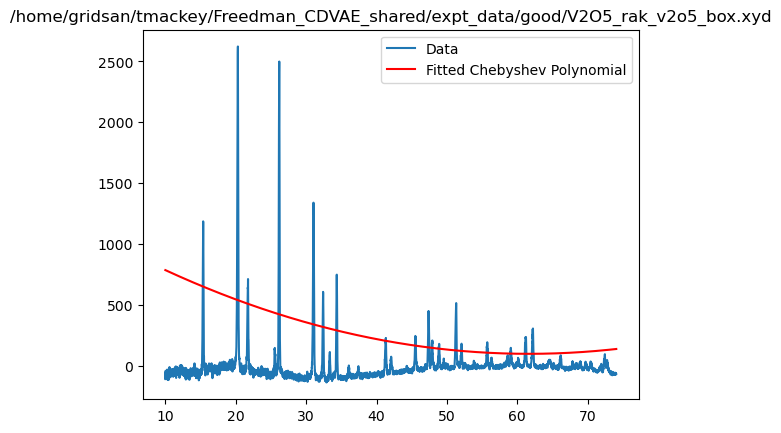

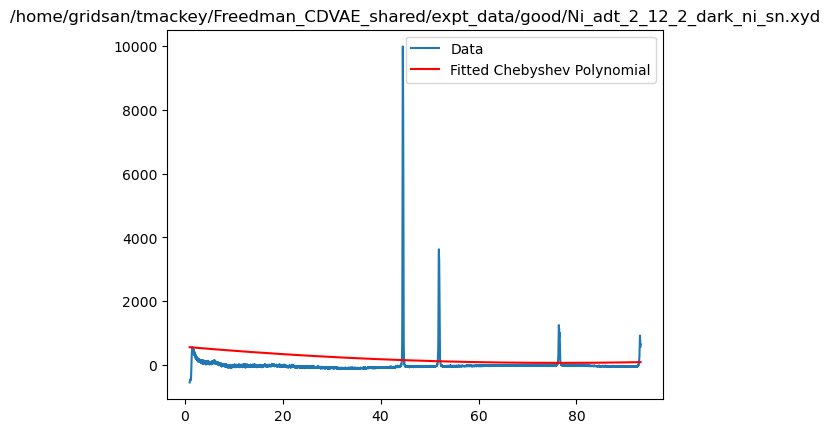

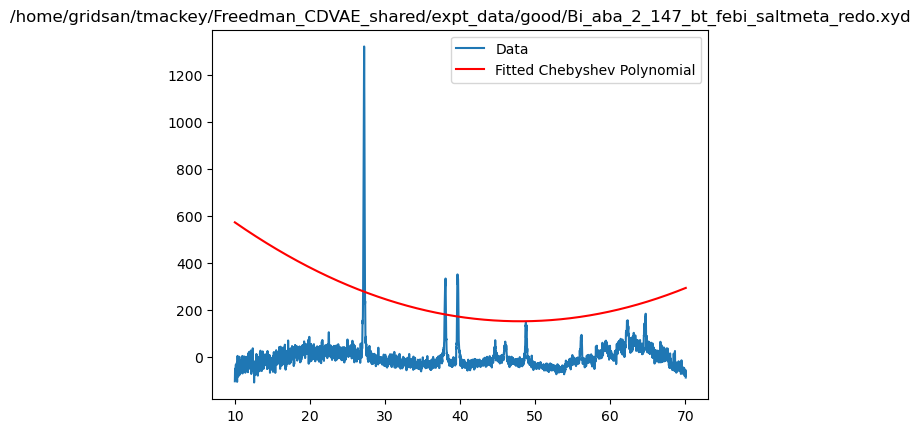

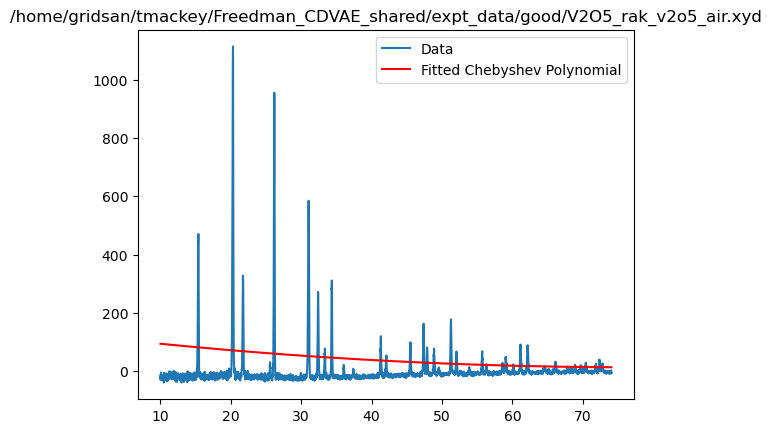

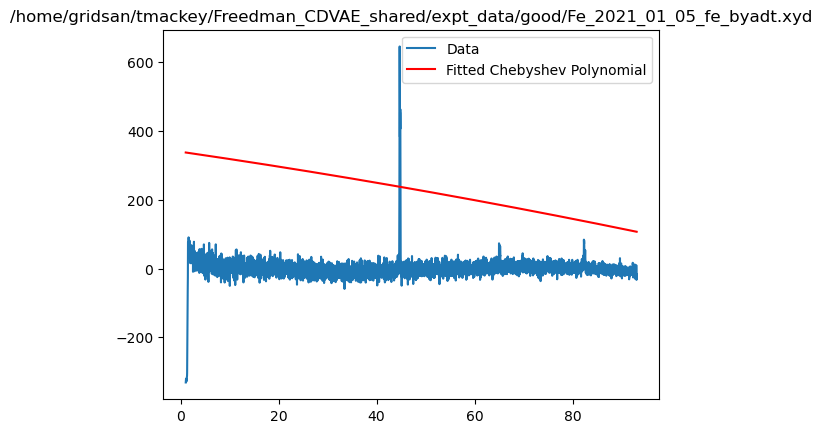

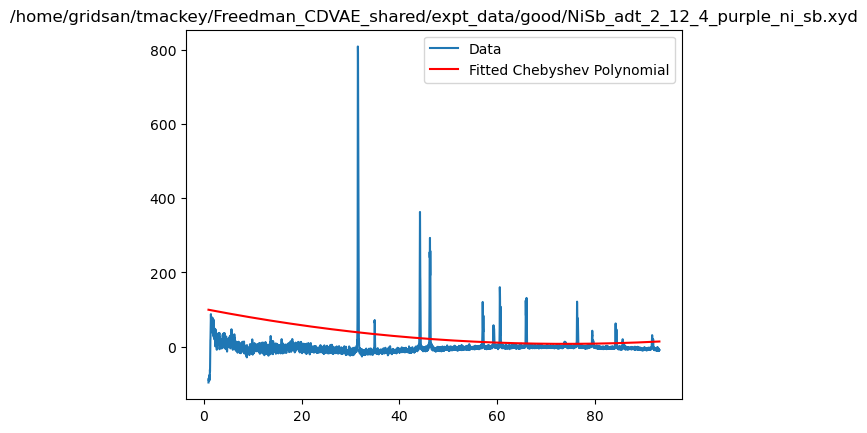

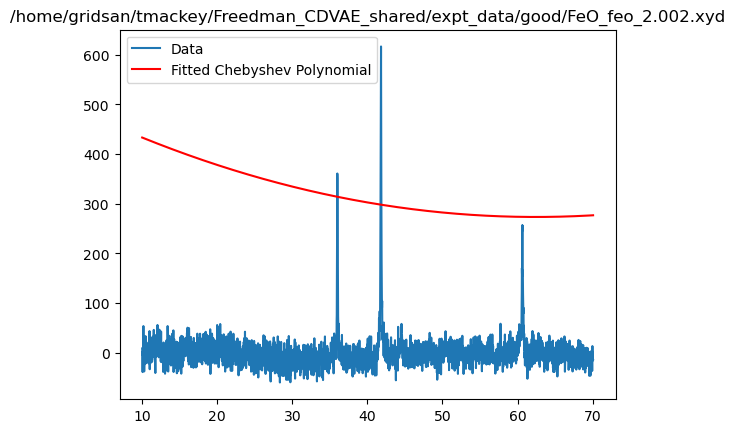

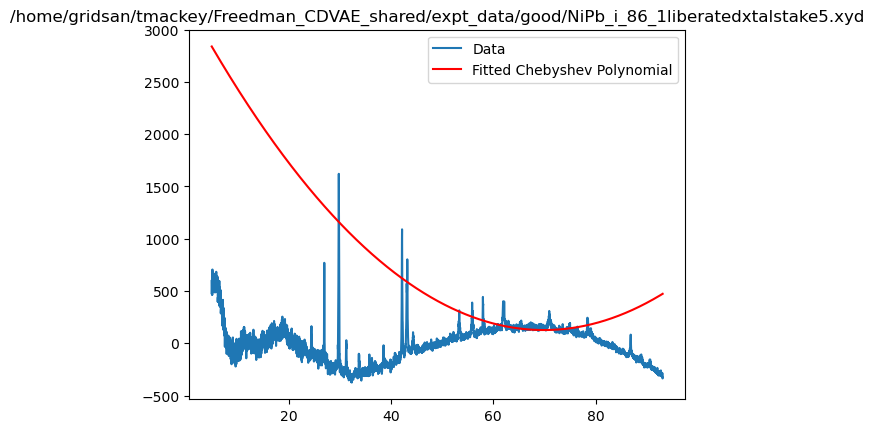

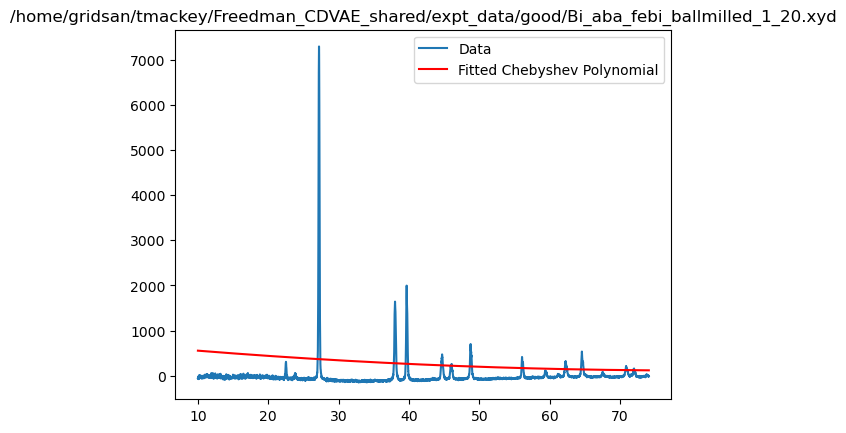

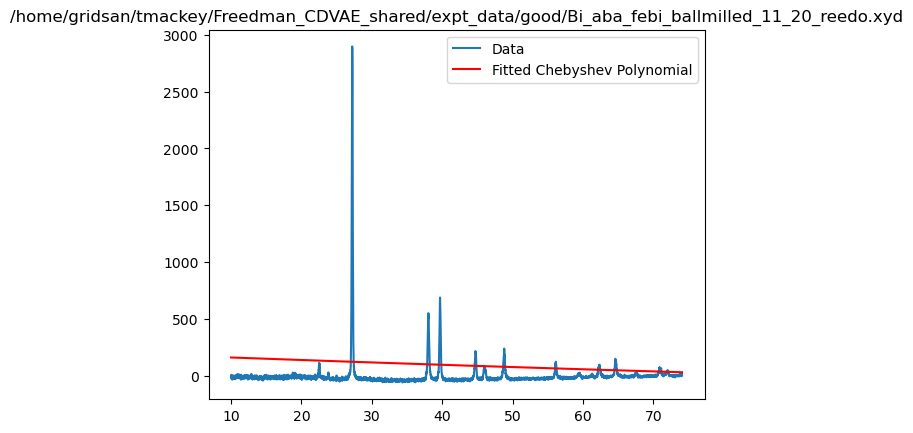

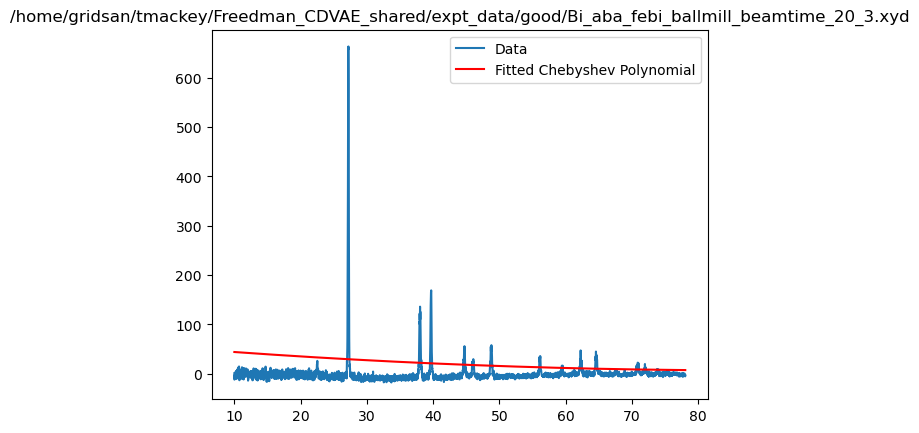

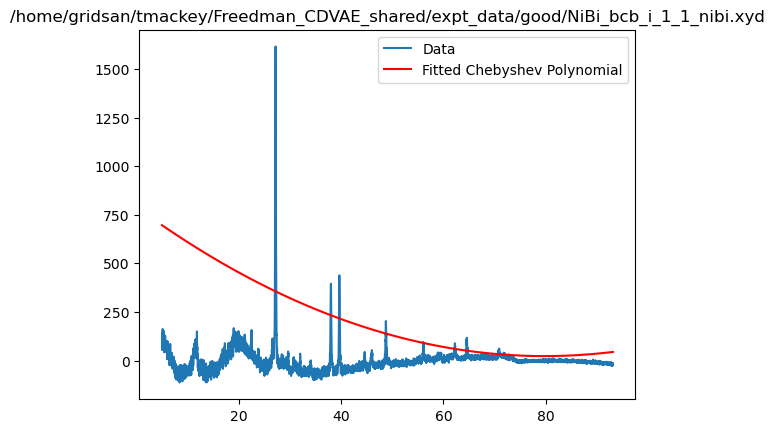

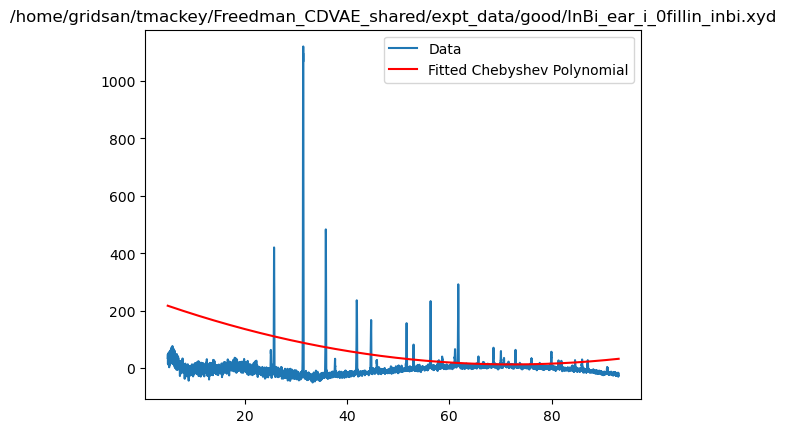

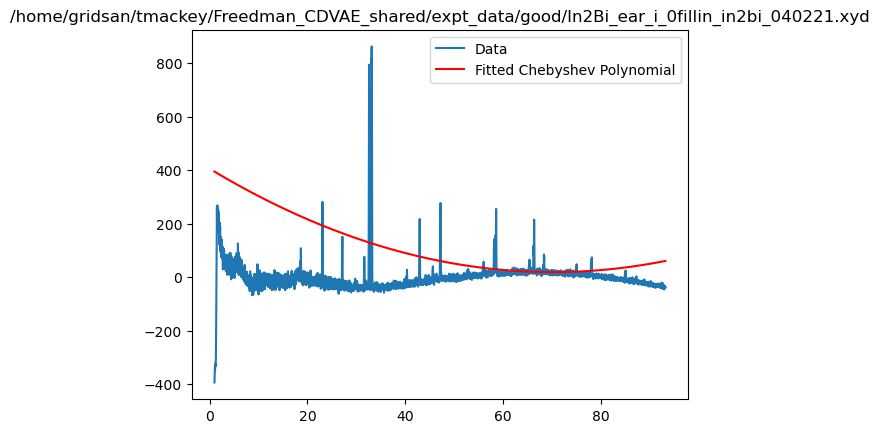

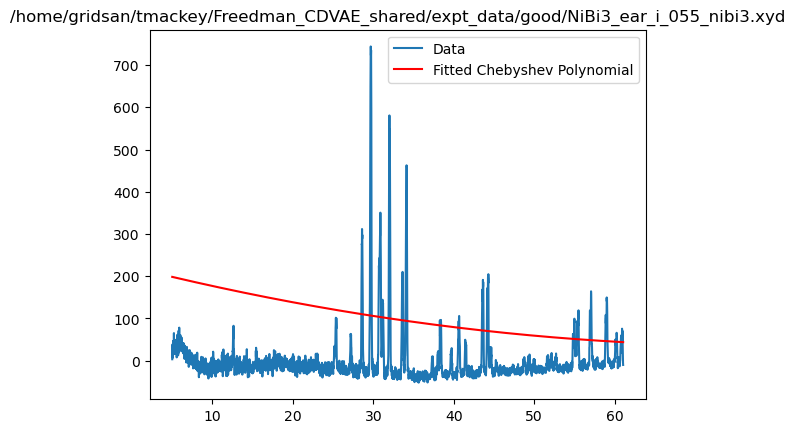

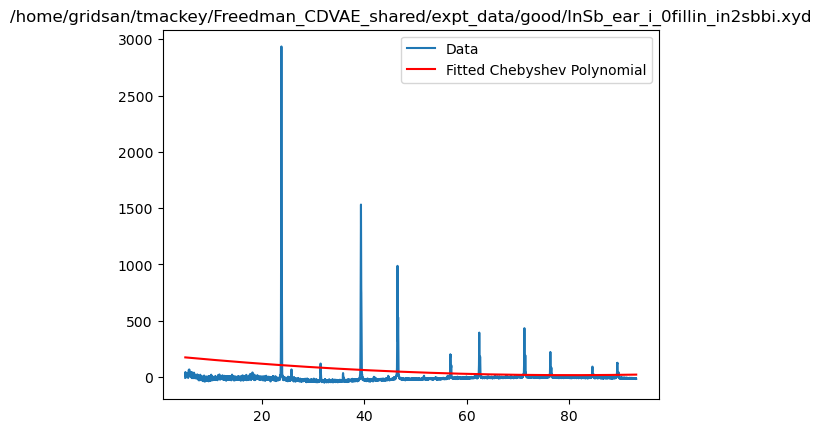

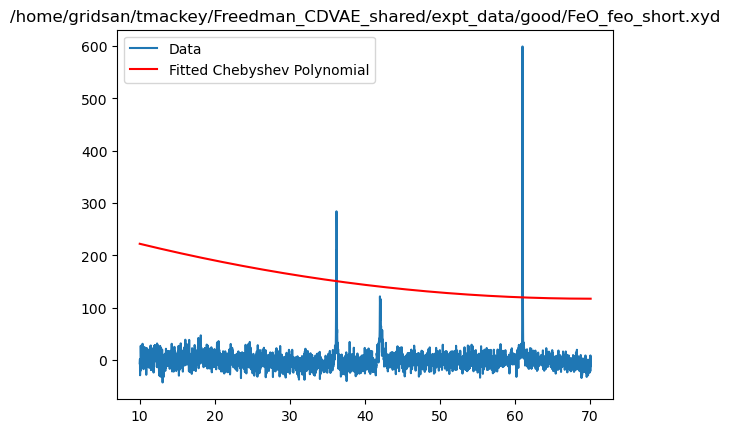

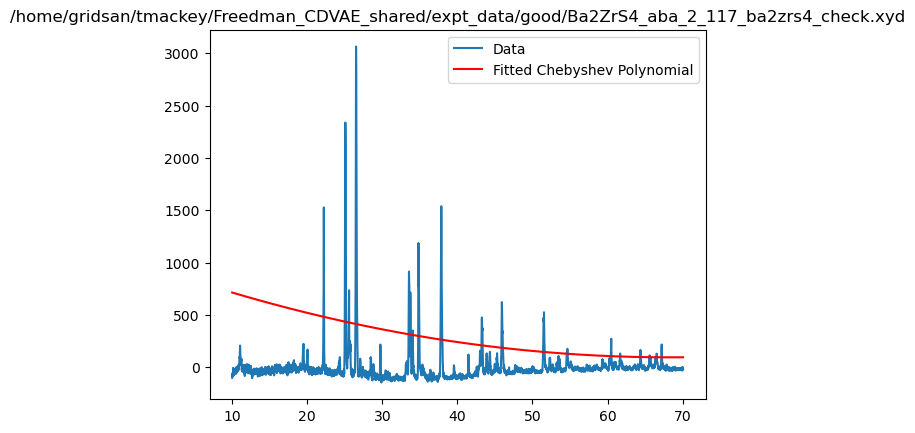

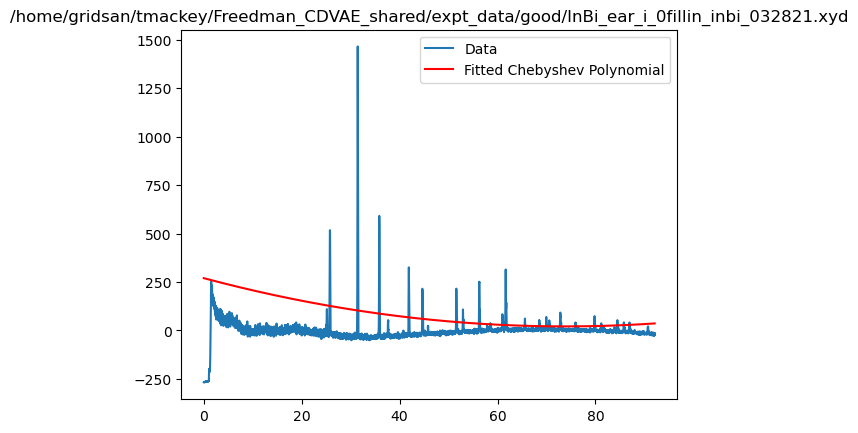

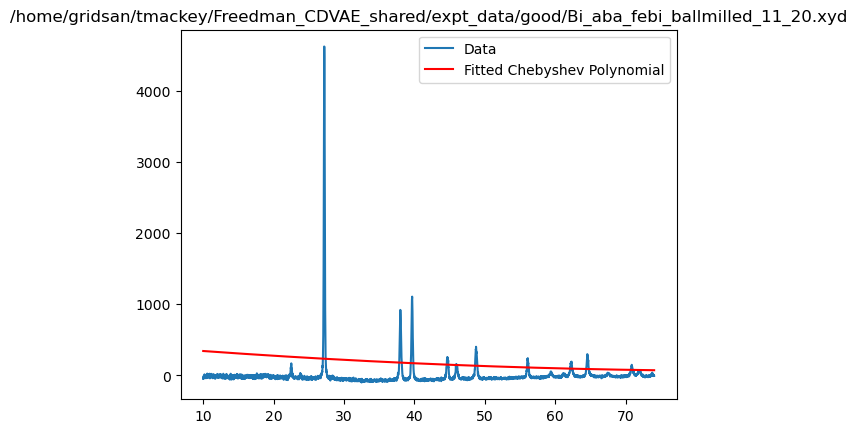

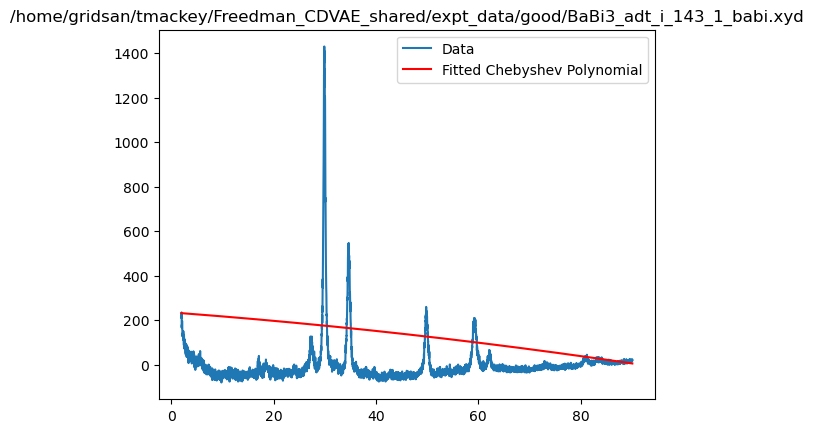

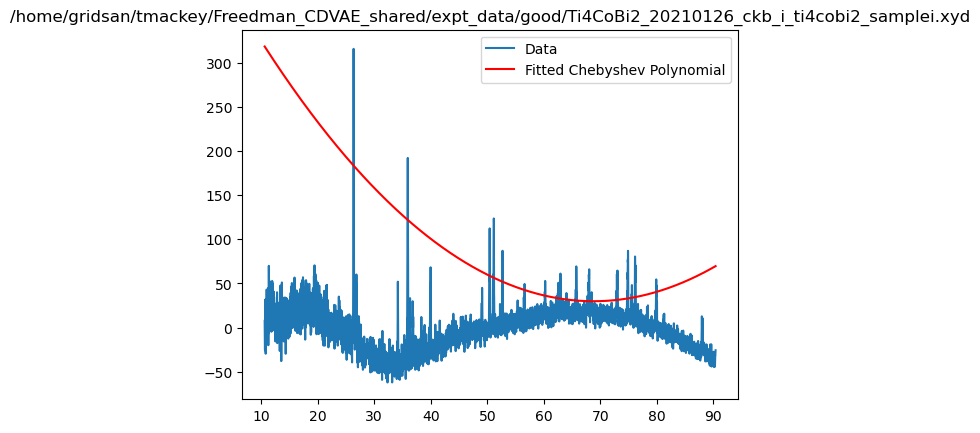

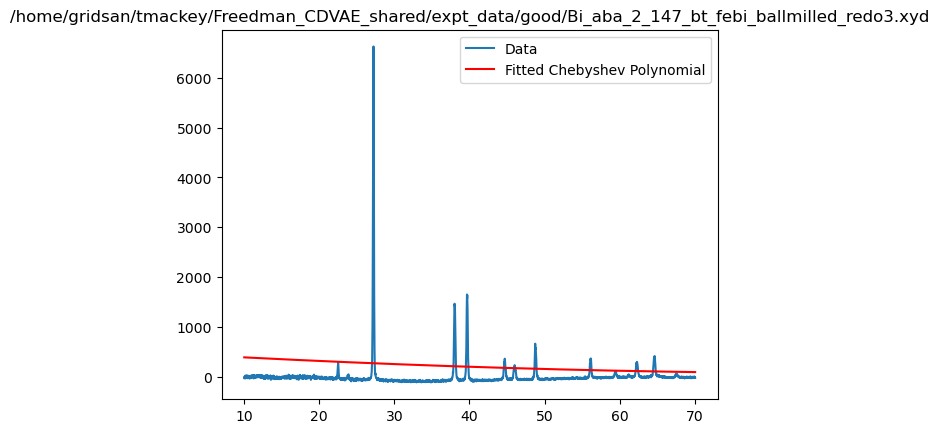

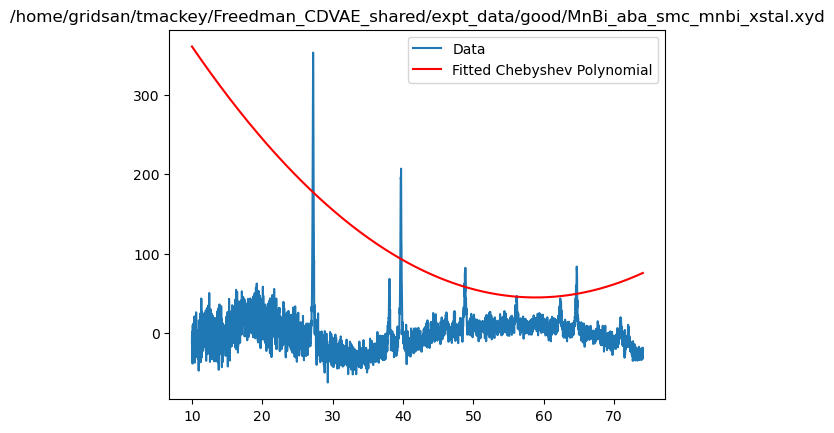

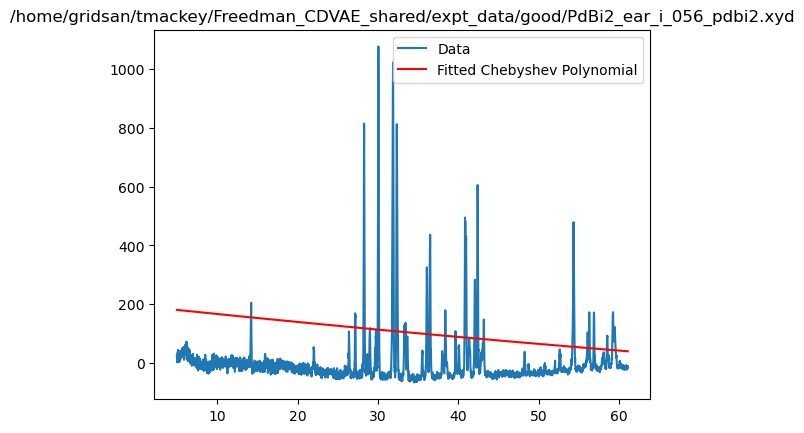

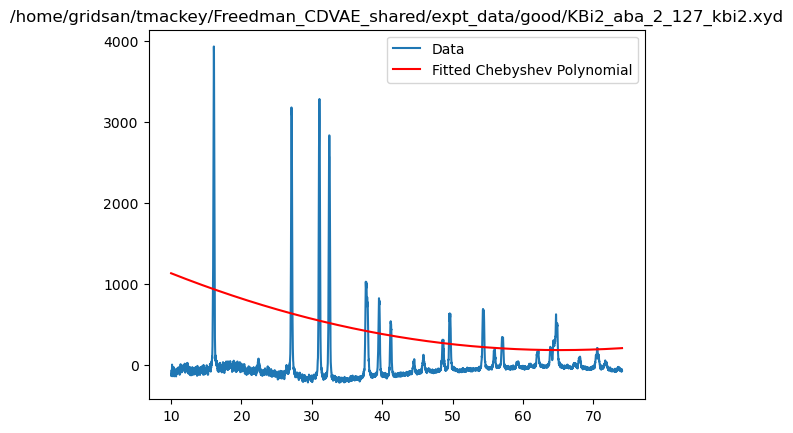

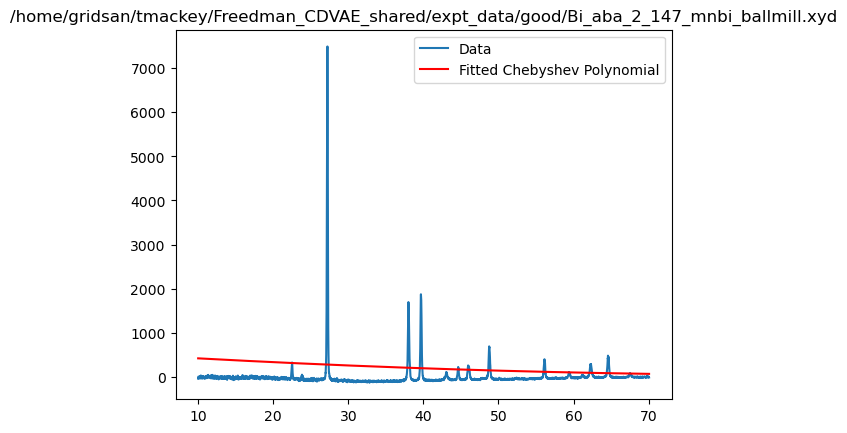

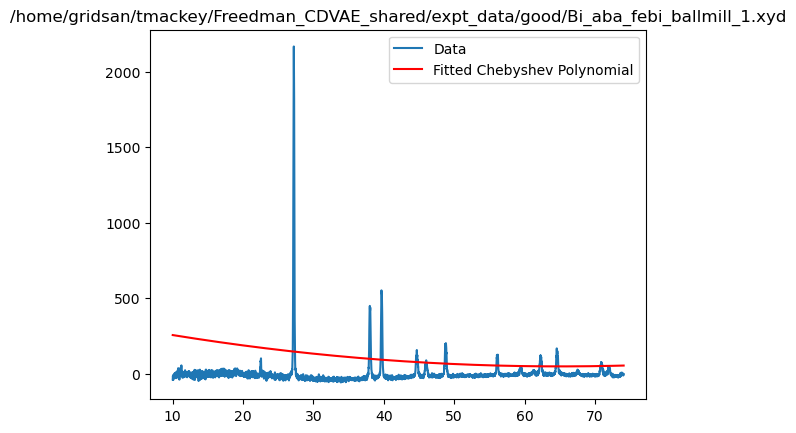

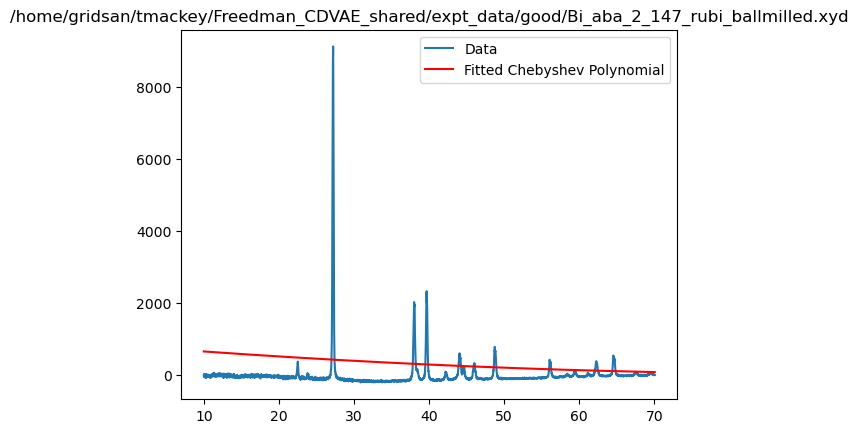

In [15]:
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev

file_list = os.listdir("/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good")

def chebyshev_fit(x, *coeffs):
    # Use the first 3 Chebyshev polynomials of the first kind
    return sum(c * chebyshev.chebval(x, [0] * i + [1]) for i, c in enumerate(coeffs))

list_totalx = []
list_totaly = []
for file in file_list[:len(file_list)]:
    file = "/home/gridsan/tmackey/Freedman_CDVAE_shared/expt_data/good/" + file
    if file.endswith(".xyd"):
        data = pd.read_csv(file, sep='\s+', header=None, names=['x', 'y', 'd'])
        x_data = np.array(data['x'])
        y_data = np.array(data['y'])

        # Provide an initial guess for the 3 coefficients
        initial_guess = [0] * 3

        popt, _ = optimize.curve_fit(chebyshev_fit, x_data, y_data, p0=initial_guess)

        # Generate fitted y values
        fit_y = chebyshev_fit(x_data, *popt)

        # Subtract fitted y values from data
        y_data = y_data - fit_y

        list_totalx.append(x_data)
        list_totaly.append(y_data)

        plt.plot(x_data, y_data, label="Data")
        plt.plot(x_data, fit_y, label="Fitted Chebyshev Polynomial", color='red')

        plt.title(file)
        plt.legend()
        plt.show()
        plt.close()
